Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step 2: Upload Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving movies.csv to movies.csv


Step 3: Load Dataset

In [ ]:
df = pd.read_csv("movies.csv")
df.head()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN


Step 4: Initial Inspection

In [ ]:
print(df.shape)
df.info()

(9999, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    9999 non-null   object 
 1   YEAR      9355 non-null   object 
 2   GENRE     9919 non-null   object 
 3   RATING    8179 non-null   float64
 4   ONE-LINE  9999 non-null   object 
 5   STARS     9999 non-null   object 
 6   VOTES     8179 non-null   object 
 7   RunTime   7041 non-null   float64
 8   Gross     460 non-null    object 
dtypes: float64(2), object(7)
memory usage: 703.2+ KB


In [ ]:
df.isnull().sum()

,0
MOVIES,0
YEAR,644
GENRE,80
RATING,1820
ONE-LINE,0
STARS,0
VOTES,1820
RunTime,2958
Gross,9539


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 431


Step 5: Remove Duplicates

In [ ]:
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()
print(df_clean.shape)

(9568, 9)


Step 6: Clean the GENRE Column

In [ ]:
df_clean['GENRE'] = df_clean['GENRE'].str.strip()
df_clean = df_clean.dropna(subset=['GENRE'])
df_clean['GENRE'].head()

,GENRE
0,"Action, Horror, Thriller"
1,"Animation, Action, Adventure"
2,"Drama, Horror, Thriller"
3,"Animation, Adventure, Comedy"
4,"Action, Crime, Horror"


Step 7: Clean the YEAR Column

In [ ]:
df_clean['YEAR_CLEAN'] = df_clean['YEAR'].str.extract(r'(\d{4})')
df_clean['YEAR_CLEAN'] = pd.to_numeric(df_clean['YEAR_CLEAN'], errors='coerce')
df_clean[['YEAR', 'YEAR_CLEAN']].head()

,YEAR,YEAR_CLEAN
0,(2021),2021.0
1,(2021– ),2021.0
2,(2010–2022),2010.0
3,(2013– ),2013.0
4,(2021),2021.0


Step 8: Clean the VOTES Column

In [ ]:
df_clean['VOTES_CLEAN'] = df_clean['VOTES'].astype(str).str.replace(',', '', regex=False)
df_clean['VOTES_CLEAN'] = pd.to_numeric(df_clean['VOTES_CLEAN'], errors='coerce')
df_clean[['VOTES', 'VOTES_CLEAN']].head()

,VOTES,VOTES_CLEAN
0,"21,062",21062.0
1,"17,870",17870.0
2,"885,805",885805.0
3,"414,849",414849.0
4,NaN,NaN


Step 9: Clean the Gross (Revenue) Column

In [ ]:
df_clean['Gross_Musd'] = df_clean['Gross'].astype(str).str.replace('$', '', regex=False).str.replace('M', '', regex=False)
df_clean['Gross_Musd'] = pd.to_numeric(df_clean['Gross_Musd'], errors='coerce')
df_clean[['Gross', 'Gross_Musd']].head()

,Gross,Gross_Musd
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


Step 10: Handle Missing Values in Key Analysis Columns

In [ ]:
# RATING is essential for "highly rated" — drop rows without it
df_clean = df_clean.dropna(subset=['RATING'])

print("Shape after cleaning:", df_clean.shape)
print("Rows with usable Gross data:", df_clean['Gross_Musd'].notnull().sum())

Shape after cleaning: (8157, 12)
Rows with usable Gross data: 460


Step 11: Split Multi-Genre Rows (Explode)

In [ ]:
df_clean['GENRE_LIST'] = df_clean['GENRE'].str.split(',').apply(lambda lst: [g.strip() for g in lst])
df_exploded = df_clean.explode('GENRE_LIST').rename(columns={'GENRE_LIST': 'GENRE_SINGLE'})

print(df_exploded.shape)
df_exploded['GENRE_SINGLE'].value_counts().head(10)

(18484, 13)


,count
GENRE_SINGLE,
Drama,3499
Comedy,2419
Action,1843
Animation,1403
Crime,1376
Adventure,1335
Documentary,1136
Thriller,777
Romance,763


Step 12: Save Cleaned Dataset

In [ ]:
df_exploded.to_csv("movies_cleaned.csv", index=False)

Step 13: Exploratory Data Analysis (EDA)

In [ ]:
df_exploded.describe()

,RATING,RunTime,YEAR_CLEAN,VOTES_CLEAN,Gross_Musd
count,18484.000000,15603.000000,18484.000000,1.848400e+04,1171.000000
mean,6.991209,67.862334,2015.701309,1.772797e+04,47.583706
std,1.205420,48.884178,7.741404,7.720554e+04,86.063621
min,1.100000,1.000000,1932.000000,5.000000e+00,0.000000
25%,6.300000,30.000000,2015.000000,1.890000e+02,0.210000
50%,7.200000,57.000000,2018.000000,9.400000e+02,10.880000
75%,7.800000,95.000000,2020.000000,4.651000e+03,56.820000
max,9.900000,853.000000,2021.000000,1.713028e+06,504.010000


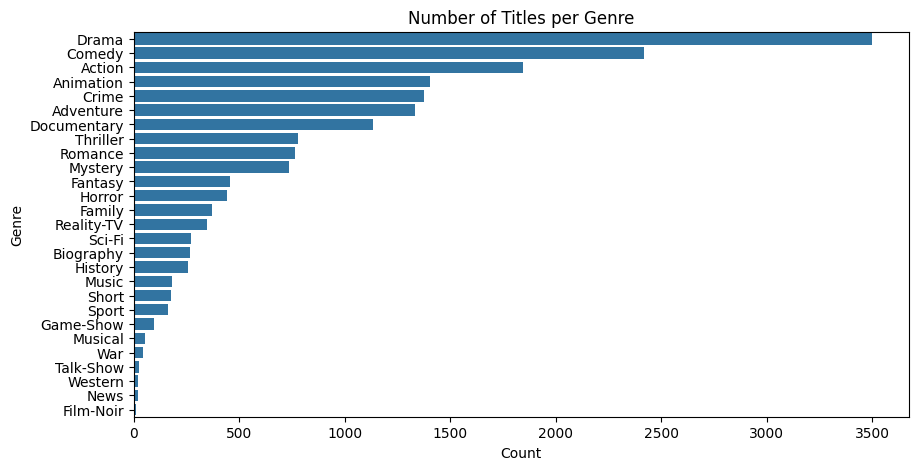

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(y='GENRE_SINGLE', data=df_exploded, order=df_exploded['GENRE_SINGLE'].value_counts().index)
plt.title("Number of Titles per Genre")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

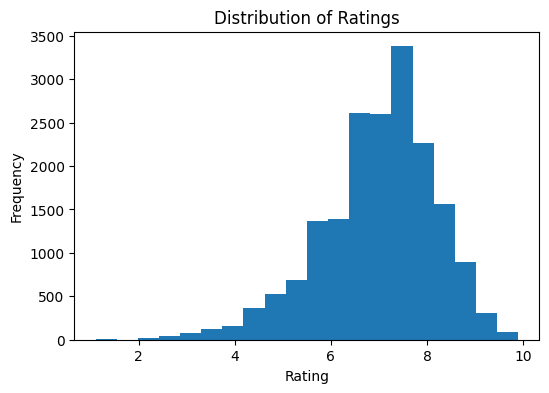

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df_exploded['RATING'].dropna(), bins=20)
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Ratings")
plt.show()

Step 14: Genre-Level Rating Analysis

In [ ]:
rating_summary = df_exploded.groupby('GENRE_SINGLE').agg(
    avg_rating=('RATING', 'mean'),
    num_titles=('RATING', 'count'),
    avg_votes=('VOTES_CLEAN', 'mean')
).round(2)

# Keep genres with enough titles to be statistically meaningful
rating_summary = rating_summary[rating_summary['num_titles'] >= 20]
rating_summary = rating_summary.sort_values('avg_rating', ascending=False)
rating_summary.head(10)

,avg_rating,num_titles,avg_votes
GENRE_SINGLE,,,
Animation,7.38,1403,9049.99
History,7.33,256,9132.70
Adventure,7.30,1335,26494.60
Documentary,7.18,1136,2576.13
Action,7.10,1843,23747.54
Mystery,7.09,737,18390.34
Drama,7.09,3499,20053.67
Crime,7.08,1376,24555.80
Biography,7.05,268,23733.22


/tmp/ipykernel_1328/3035153843.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_rated['avg_rating'], y=top_rated.index, palette="viridis")


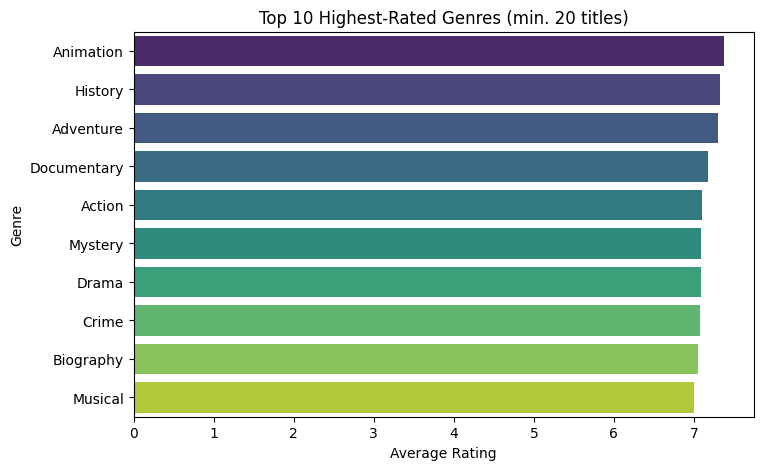

In [ ]:
plt.figure(figsize=(8,5))
top_rated = rating_summary.head(10)
sns.barplot(x=top_rated['avg_rating'], y=top_rated.index, palette="viridis")
plt.title("Top 10 Highest-Rated Genres (min. 20 titles)")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.show()

Step 15: Genre-Level Profitability Analysis

In [ ]:
gross_df = df_exploded.dropna(subset=['Gross_Musd'])
print("Titles with gross data:", gross_df.shape[0])

gross_summary = gross_df.groupby('GENRE_SINGLE').agg(
    avg_gross=('Gross_Musd', 'mean'),
    total_gross=('Gross_Musd', 'sum'),
    num_titles=('Gross_Musd', 'count')
).round(2)

# Keep genres with at least 5 titles that report gross
gross_summary = gross_summary[gross_summary['num_titles'] >= 5]
gross_summary = gross_summary.sort_values('avg_gross', ascending=False)
gross_summary.head(10)

Titles with gross data: 1171


,avg_gross,total_gross,num_titles
GENRE_SINGLE,,,
Musical,169.79,848.93,5
Sci-Fi,126.21,3407.59,27
Adventure,113.14,11313.96,100
Animation,71.92,3452.38,48
Action,71.37,9634.30,135
Family,67.01,1206.12,18
Fantasy,64.94,2272.95,35
Comedy,54.37,6524.21,120
Thriller,42.87,2914.91,68


/tmp/ipykernel_1328/597786656.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_gross['avg_gross'], y=top_gross.index, palette="mako")


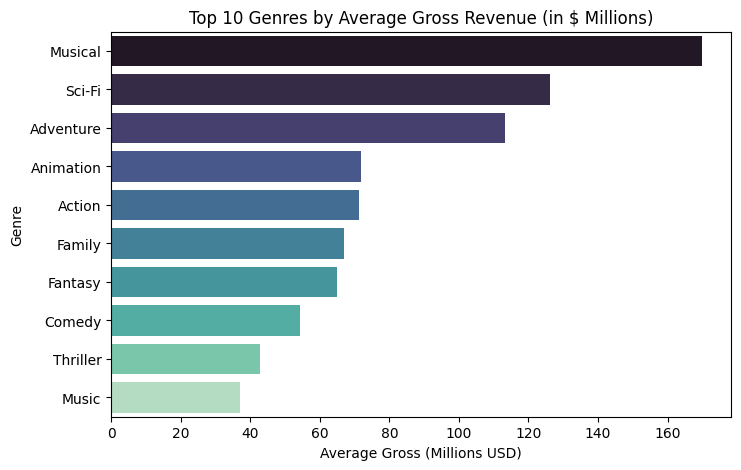

In [ ]:
plt.figure(figsize=(8,5))
top_gross = gross_summary.head(10)
sns.barplot(x=top_gross['avg_gross'], y=top_gross.index, palette="mako")
plt.title("Top 10 Genres by Average Gross Revenue (in $ Millions)")
plt.xlabel("Average Gross (Millions USD)")
plt.ylabel("Genre")
plt.show()

Step 16: Combine Rating and Profitability into One Score

In [ ]:
combined = rating_summary.join(gross_summary, how='inner', rsuffix='_gross')

# Normalize both metrics to a 0–1 scale so rating and gross are comparable
combined['rating_norm'] = (combined['avg_rating'] - combined['avg_rating'].min()) / (combined['avg_rating'].max() - combined['avg_rating'].min())
combined['gross_norm'] = (combined['avg_gross'] - combined['avg_gross'].min()) / (combined['avg_gross'].max() - combined['avg_gross'].min())

combined['combined_score'] = (combined['rating_norm'] + combined['gross_norm']) / 2
combined = combined.sort_values('combined_score', ascending=False)
combined

,avg_rating,num_titles,avg_votes,avg_gross,total_gross,num_titles_gross,rating_norm,gross_norm,combined_score
GENRE_SINGLE,,,,,,,,,
Musical,7.00,52,21328.63,169.79,848.93,5,0.750000,1.000000,0.875000
Adventure,7.30,1335,26494.60,113.14,11313.96,100,0.947368,0.663399,0.805384
Animation,7.38,1403,9049.99,71.92,3452.38,48,1.000000,0.418479,0.709239
Action,7.10,1843,23747.54,71.37,9634.30,135,0.815789,0.415211,0.615500
Sci-Fi,6.58,270,45276.44,126.21,3407.59,27,0.473684,0.741058,0.607371
Fantasy,7.00,455,25334.65,64.94,2272.95,35,0.750000,0.377005,0.563503
History,7.33,256,9132.70,6.62,172.21,26,0.967105,0.030481,0.498793
Family,6.77,371,11522.33,67.01,1206.12,18,0.598684,0.389305,0.493995
Crime,7.08,1376,24555.80,32.18,2831.61,88,0.802632,0.182353,0.492492


Step 17: Visualize the Final Ranking

/tmp/ipykernel_1328/542849135.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=combined['combined_score'], y=combined.index, palette="rocket")


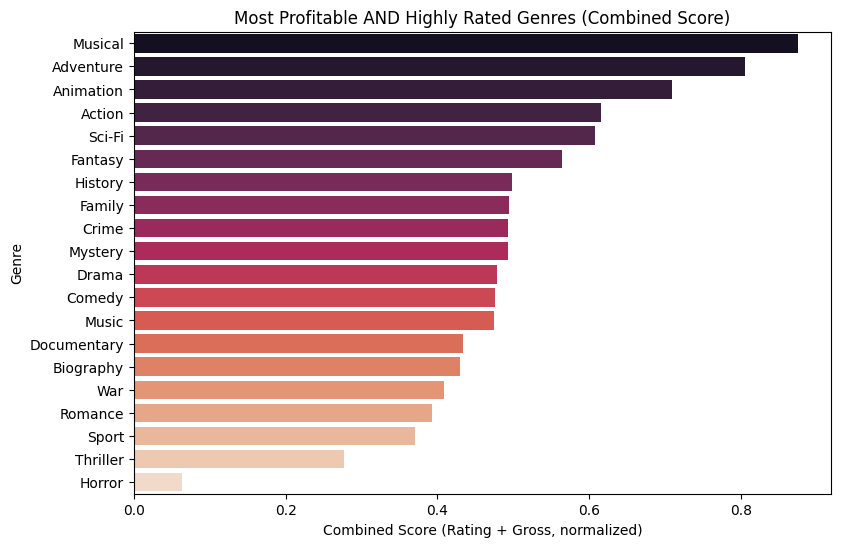

In [ ]:
plt.figure(figsize=(9,6))
sns.barplot(x=combined['combined_score'], y=combined.index, palette="rocket")
plt.title("Most Profitable AND Highly Rated Genres (Combined Score)")
plt.xlabel("Combined Score (Rating + Gross, normalized)")
plt.ylabel("Genre")
plt.show()

Step 18: Rating vs. Gross Scatter Plot (Genre-Level)

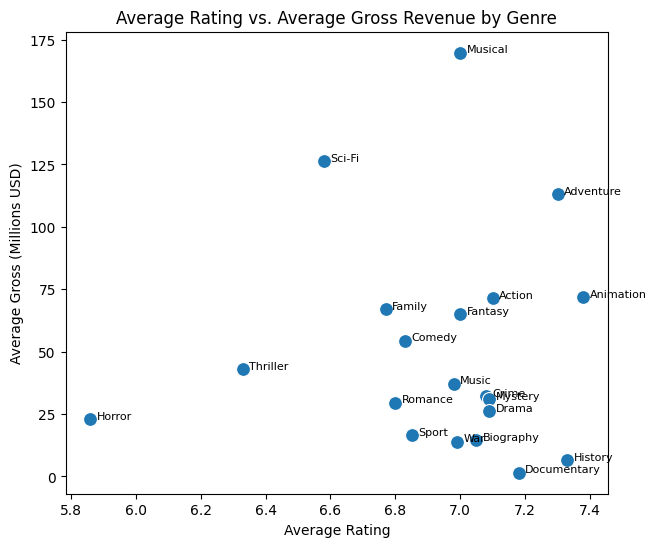

In [ ]:
plt.figure(figsize=(7,6))
sns.scatterplot(data=combined, x='avg_rating', y='avg_gross', s=100)
for genre in combined.index:
    plt.text(combined.loc[genre, 'avg_rating']+0.02, combined.loc[genre, 'avg_gross'], genre, fontsize=8)
plt.title("Average Rating vs. Average Gross Revenue by Genre")
plt.xlabel("Average Rating")
plt.ylabel("Average Gross (Millions USD)")
plt.show()